# 01 — Analyse Exploratoire et Préparation des Données
**Binôme A** | Credit Card Fraud Detection

### Ce notebook produit :
- `data/processed/train.csv`
- `data/processed/val.csv`
- `data/processed/test.csv`

### Plan :
1. Exploration basique
2. Feature Engineering (`Time`, `Amount`)
3. Analyse de colinéarité (corrélation + VIF)
4. Comparaison SMOTE vs `class_weight`
5. Export des splits

---
## 0. Imports & Configuration

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, average_precision_score, matthews_corrcoef

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from imblearn.over_sampling import SMOTE, ADASYN

# ── Config partagée ──────────────────────────────────────────────
RANDOM_SEED    = 42
TEST_SIZE      = 0.20
VAL_SIZE       = 0.10
DATA_PATH      = '../data/raw/creditcard.csv'
PROCESSED_PATH = '../data/processed/'
PLOTS_PATH     = '../plots/'

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(PLOTS_PATH,     exist_ok=True)

np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Setup OK')

✅ Setup OK


---
## 1. Exploration Basique

In [12]:
df = pd.read_csv(DATA_PATH)
print(f'Shape : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
df.head(3)

Shape : 284,807 lignes × 31 colonnes


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [13]:
# ── Types & valeurs manquantes ───────────────────────────────────
summary = pd.DataFrame({
    'dtype'    : df.dtypes,
    'nulls'    : df.isnull().sum(),
    'null_%'   : (df.isnull().mean() * 100).round(3),
    'unique'   : df.nunique(),
    'min'      : df.min(),
    'max'      : df.max()
})
print(summary.to_string())
print('\n✅ Aucune valeur manquante' if df.isnull().sum().sum() == 0 else '⚠️  Valeurs manquantes détectées')

          dtype  nulls  null_%  unique         min            max
Time    float64      0     0.0  124592    0.000000  172792.000000
V1      float64      0     0.0  275663  -56.407510       2.454930
V2      float64      0     0.0  275663  -72.715728      22.057729
V3      float64      0     0.0  275663  -48.325589       9.382558
V4      float64      0     0.0  275663   -5.683171      16.875344
V5      float64      0     0.0  275663 -113.743307      34.801666
V6      float64      0     0.0  275663  -26.160506      73.301626
V7      float64      0     0.0  275663  -43.557242     120.589494
V8      float64      0     0.0  275663  -73.216718      20.007208
V9      float64      0     0.0  275663  -13.434066      15.594995
V10     float64      0     0.0  275663  -24.588262      23.745136
V11     float64      0     0.0  275663   -4.797473      12.018913
V12     float64      0     0.0  275663  -18.683715       7.848392
V13     float64      0     0.0  275663   -5.791881       7.126883
V14     fl

═══════════════════════════════════════
       DISTRIBUTION DES CLASSES        
═══════════════════════════════════════
  Légitimes   (0) :  284,315  (99.8273%)
  Frauduleuses(1) :      492  (0.1727%)
  Ratio                  577:1
═══════════════════════════════════════


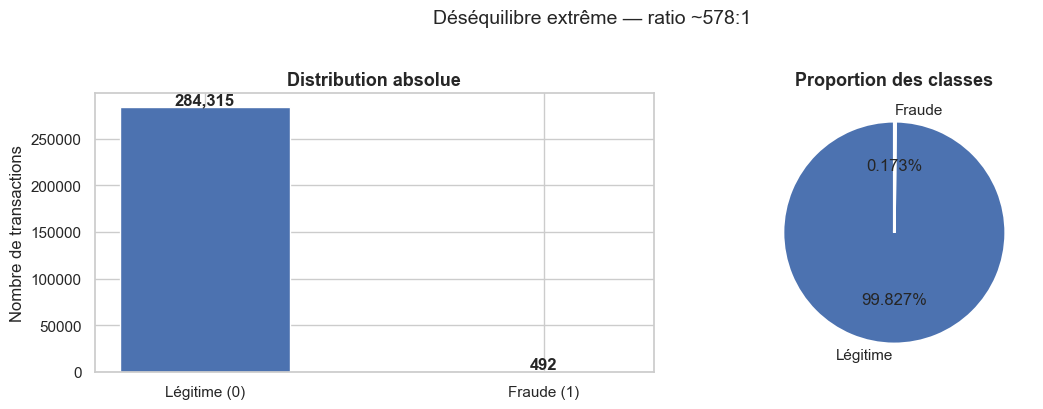

In [14]:
# ── Distribution des classes ─────────────────────────────────────
counts = df['Class'].value_counts()
pcts   = df['Class'].value_counts(normalize=True) * 100

print('═══════════════════════════════════════')
print('       DISTRIBUTION DES CLASSES        ')
print('═══════════════════════════════════════')
print(f'  Légitimes   (0) : {counts[0]:>8,}  ({pcts[0]:.4f}%)')
print(f'  Frauduleuses(1) : {counts[1]:>8,}  ({pcts[1]:.4f}%)')
print(f'  Ratio             {counts[0]//counts[1]:>8}:1')
print('═══════════════════════════════════════')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Absolu
bars = axes[0].bar(['Légitime (0)', 'Fraude (1)'],
                    counts.values, color=['#4C72B0', '#C44E52'], edgecolor='white', width=0.5)
axes[0].set_title('Distribution absolue', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de transactions')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=['Légitime', 'Fraude'],
            autopct='%1.3f%%', colors=['#4C72B0', '#C44E52'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')

plt.suptitle('Déséquilibre extrême — ratio ~578:1', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Statistiques descriptives par classe ─────────────────────────
print('=== Statistiques : Transactions LÉGITIMES ===')
display(df[df['Class']==0][['Amount','Time']].describe().round(2))

print('\n=== Statistiques : Transactions FRAUDULEUSES ===')
display(df[df['Class']==1][['Amount','Time']].describe().round(2))

=== Statistiques : Transactions LÉGITIMES ===


,Amount,Time
count,284315.00,284315.00
mean,88.29,94838.20
std,250.11,47484.02
min,0.00,0.00
25%,5.65,54230.00
50%,22.00,84711.00
75%,77.05,139333.00
max,25691.16,172792.00



=== Statistiques : Transactions FRAUDULEUSES ===


,Amount,Time
count,492.00,492.00
mean,122.21,80746.81
std,256.68,47835.37
min,0.00,406.00
25%,1.00,41241.50
50%,9.25,75568.50
75%,105.89,128483.00
max,2125.87,170348.00


---
## 2. Feature Engineering

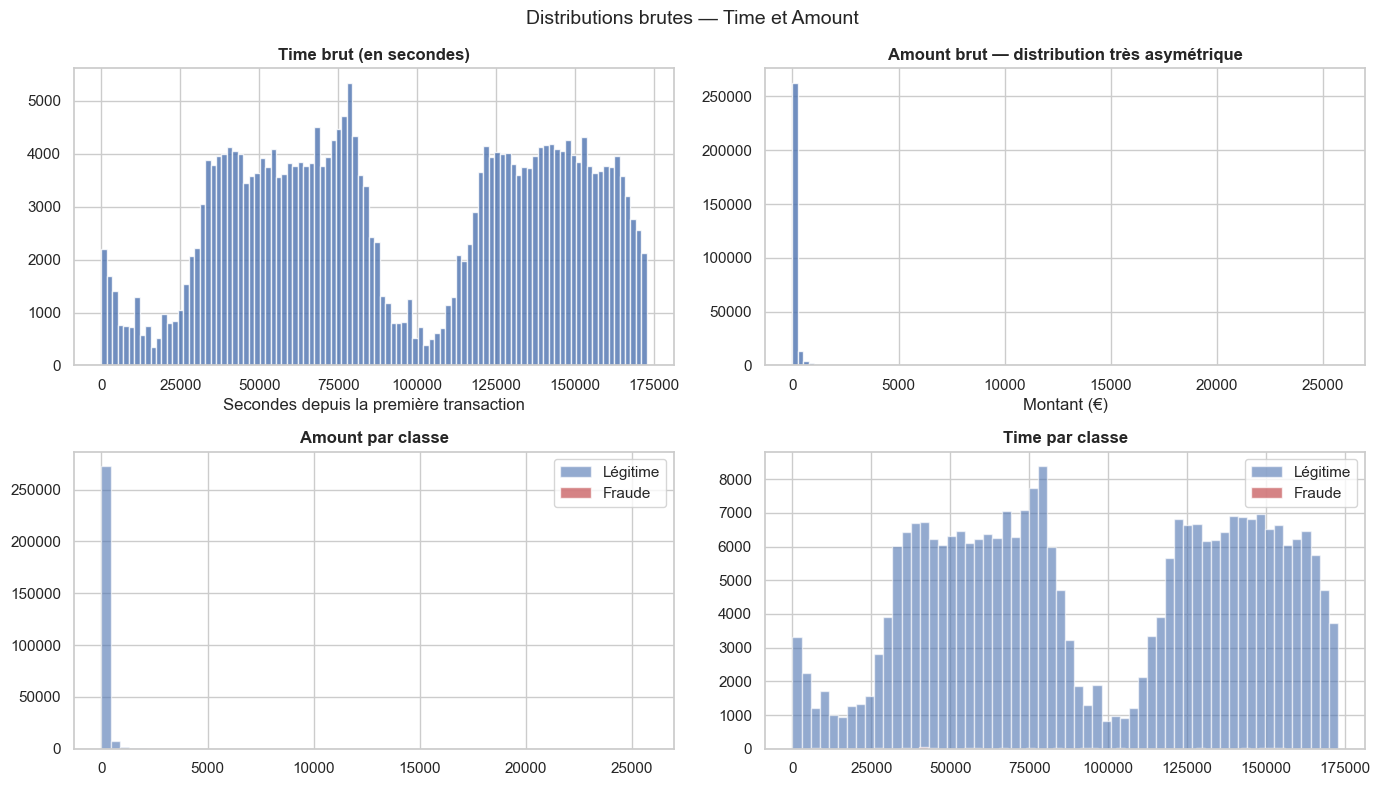

In [16]:
# ── Visualiser Time et Amount AVANT transformation ────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Time — distribution globale
axes[0,0].hist(df['Time'], bins=100, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0,0].set_title('Time brut (en secondes)', fontweight='bold')
axes[0,0].set_xlabel('Secondes depuis la première transaction')

# Amount — très skewed
axes[0,1].hist(df['Amount'], bins=100, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0,1].set_title('Amount brut — distribution très asymétrique', fontweight='bold')
axes[0,1].set_xlabel('Montant (€)')

# Amount par classe
df[df['Class']==0]['Amount'].hist(ax=axes[1,0], bins=60, alpha=0.6, label='Légitime', color='#4C72B0')
df[df['Class']==1]['Amount'].hist(ax=axes[1,0], bins=60, alpha=0.7, label='Fraude',   color='#C44E52')
axes[1,0].set_title('Amount par classe', fontweight='bold')
axes[1,0].legend()

# Time par classe
df[df['Class']==0]['Time'].hist(ax=axes[1,1], bins=60, alpha=0.6, label='Légitime', color='#4C72B0')
df[df['Class']==1]['Time'].hist(ax=axes[1,1], bins=60, alpha=0.7, label='Fraude',   color='#C44E52')
axes[1,1].set_title('Time par classe', fontweight='bold')
axes[1,1].legend()

plt.suptitle('Distributions brutes — Time et Amount', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}02_raw_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Création des nouvelles features ──────────────────────────────
df_eng = df.copy()

# 1. Log-transform Amount
#    Justification : Amount est très skewed (max=25691, moyenne=88)
#    log1p évite log(0) pour les montants nuls
df_eng['Amount_log'] = np.log1p(df_eng['Amount'])

# 2. Heure de la journée
#    Justification : Time est en secondes cumulées — on extrait le cycle journalier
#    Le dataset couvre ~2 jours donc % 86400 donne l'heure réelle
df_eng['Hour'] = (df_eng['Time'] % 86400) // 3600

# 3. Supprimer les features originales remplacées
df_eng = df_eng.drop(columns=['Time', 'Amount'])

print('Features créées   :', ['Amount_log', 'Hour'])
print('Features supprimées: [Time, Amount]')
print(f'Shape final        : {df_eng.shape}')
df_eng.head(3)

Features créées   : ['Amount_log', 'Hour']
Features supprimées: [Time, Amount]
Shape final        : (284807, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,Amount_log,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,5.014760,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,1.305626,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,5.939276,0.0


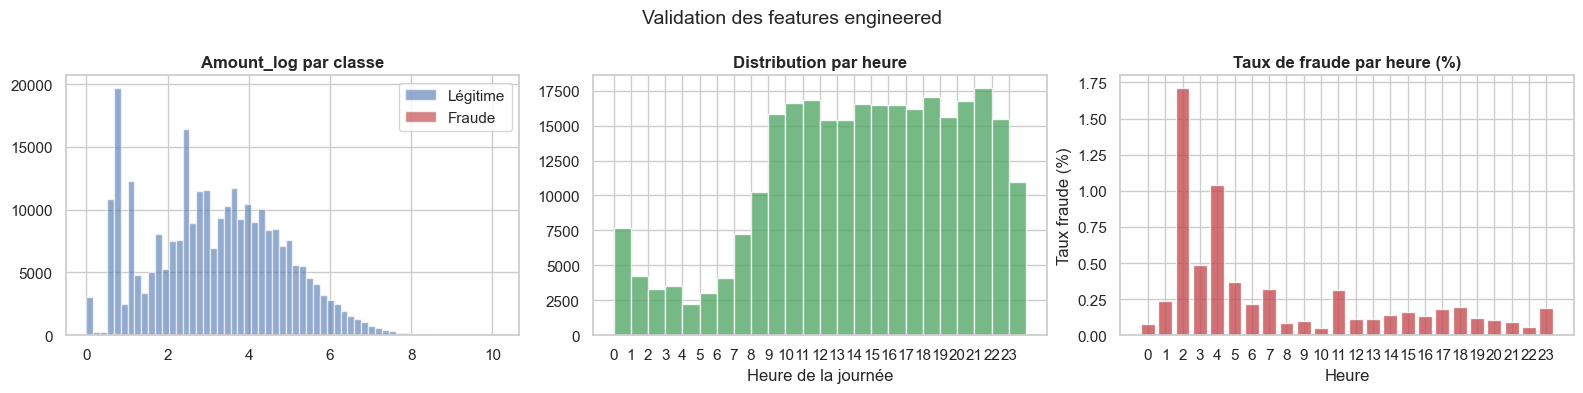


Taux fraude moyen global : 0.173%
Heure avec le plus de fraudes : 2.0h (1.71%)


In [18]:
# ── Valider les nouvelles features ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Amount_log
df_eng[df_eng['Class']==0]['Amount_log'].hist(ax=axes[0], bins=60, alpha=0.6, label='Légitime', color='#4C72B0')
df_eng[df_eng['Class']==1]['Amount_log'].hist(ax=axes[0], bins=60, alpha=0.7, label='Fraude',   color='#C44E52')
axes[0].set_title('Amount_log par classe', fontweight='bold')
axes[0].legend()

# Distribution par heure
axes[1].hist(df_eng['Hour'], bins=24, range=(0,24), color='#55A868', alpha=0.8, edgecolor='white')
axes[1].set_title('Distribution par heure', fontweight='bold')
axes[1].set_xlabel('Heure de la journée')
axes[1].set_xticks(range(0, 24))

# Taux de fraude par heure
fraud_rate = df_eng.groupby('Hour')['Class'].mean() * 100
axes[2].bar(fraud_rate.index, fraud_rate.values, color='#C44E52', alpha=0.8, edgecolor='white')
axes[2].set_title('Taux de fraude par heure (%)', fontweight='bold')
axes[2].set_xlabel('Heure')
axes[2].set_ylabel('Taux fraude (%)')
axes[2].set_xticks(range(0, 24))

plt.suptitle('Validation des features engineered', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}03_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTaux fraude moyen global : {df_eng['Class'].mean()*100:.3f}%")
print(f"Heure avec le plus de fraudes : {fraud_rate.idxmax()}h ({fraud_rate.max():.2f}%)")

---
## 3. Analyse de Colinéarité

> **Note :** V1–V28 sont les composantes d'une PCA — orthogonaux par construction. On s'attend donc à un VIF faible. L'analyse reste nécessaire pour valider cette hypothèse et analyser nos features engineered.

In [19]:
# ── 3.1 Matrice de corrélation ────────────────────────────────────
corr = df_eng.corr()

# Top corrélations avec la target
corr_target = corr['Class'].drop('Class').sort_values(key=abs, ascending=False)

print('═══════════════════════════════════════════')
print('  Top 15 corrélations avec Class (Fraude)  ')
print('═══════════════════════════════════════════')
for feat, val in corr_target.head(15).items():
    bar = '█' * int(abs(val) * 30)
    direction = '↑' if val > 0 else '↓'
    print(f'  {feat:<15} {val:+.4f}  {direction} {bar}')

═══════════════════════════════════════════
  Top 15 corrélations avec Class (Fraude)  
═══════════════════════════════════════════
  V17             -0.3265  ↓ █████████
  V14             -0.3025  ↓ █████████
  V12             -0.2606  ↓ ███████
  V10             -0.2169  ↓ ██████
  V16             -0.1965  ↓ █████
  V3              -0.1930  ↓ █████
  V7              -0.1873  ↓ █████
  V11             +0.1549  ↑ ████
  V4              +0.1334  ↑ ████
  V18             -0.1115  ↓ ███
  V1              -0.1013  ↓ ███
  V9              -0.0977  ↓ ██
  V5              -0.0950  ↓ ██
  V2              +0.0913  ↑ ██
  V6              -0.0436  ↓ █


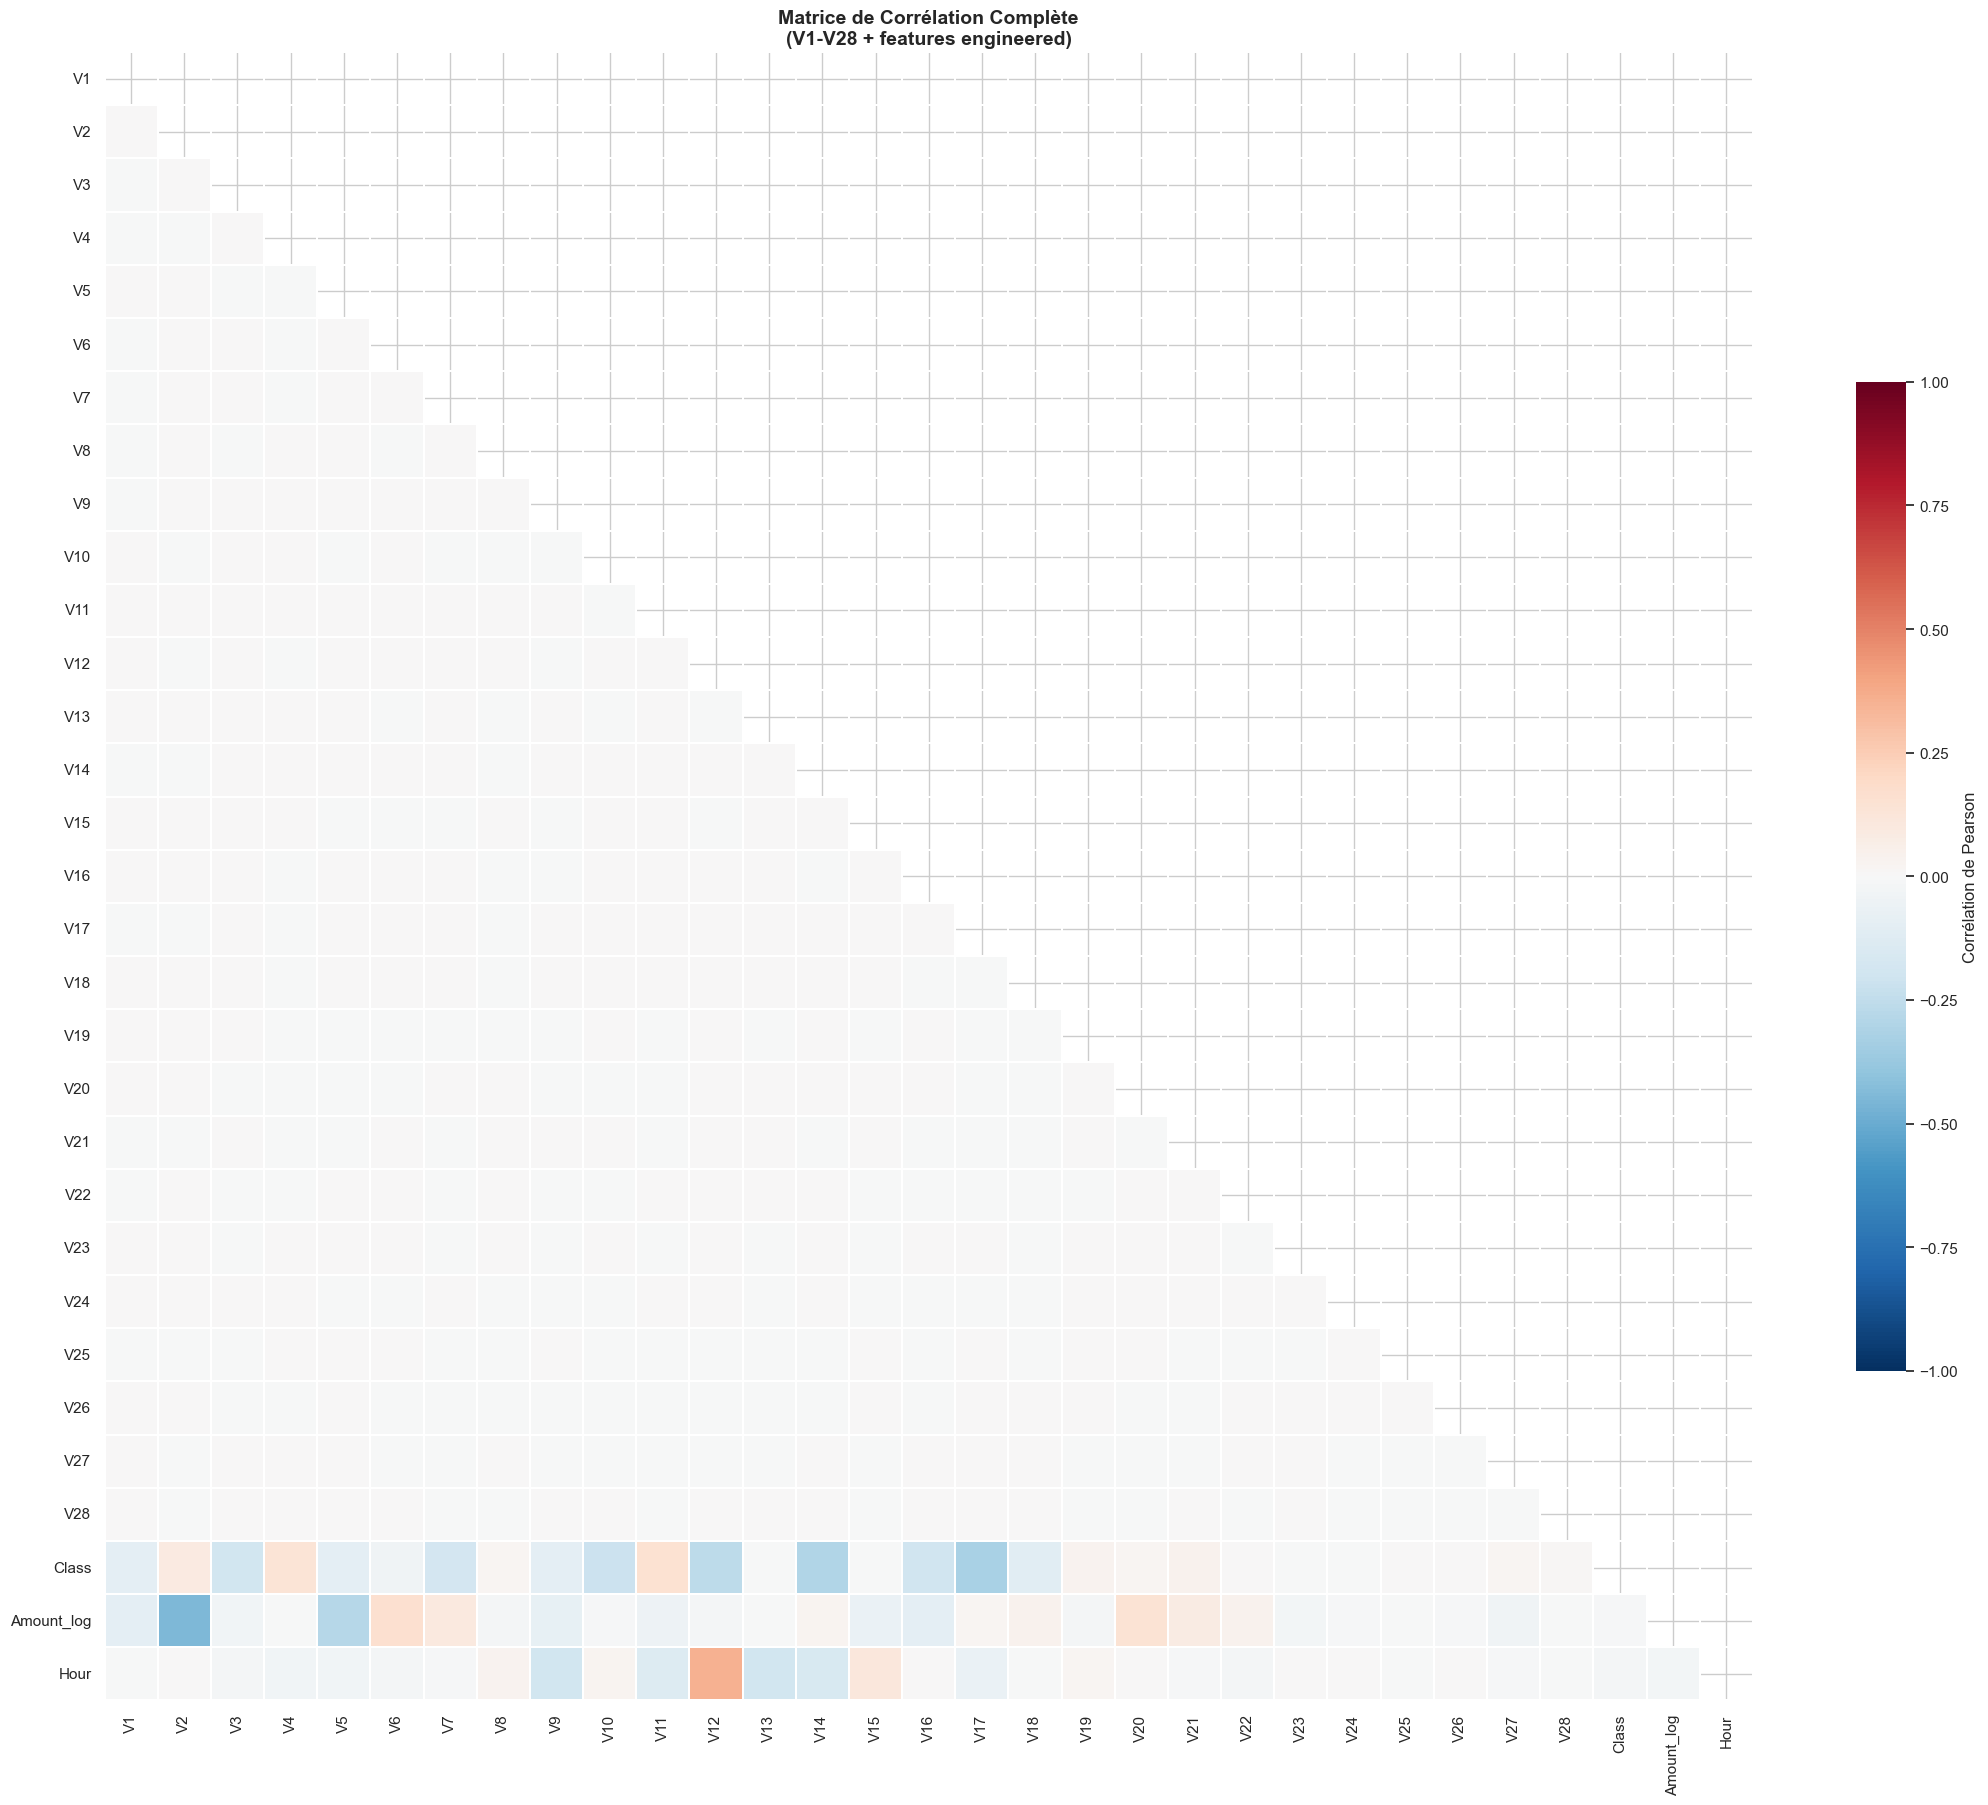

In [20]:
# Heatmap complète
plt.figure(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True,
            linewidths=0.3, linecolor='white',
            cbar_kws={'shrink': 0.6, 'label': 'Corrélation de Pearson'},
            annot=False)
plt.title('Matrice de Corrélation Complète\n(V1-V28 + features engineered)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

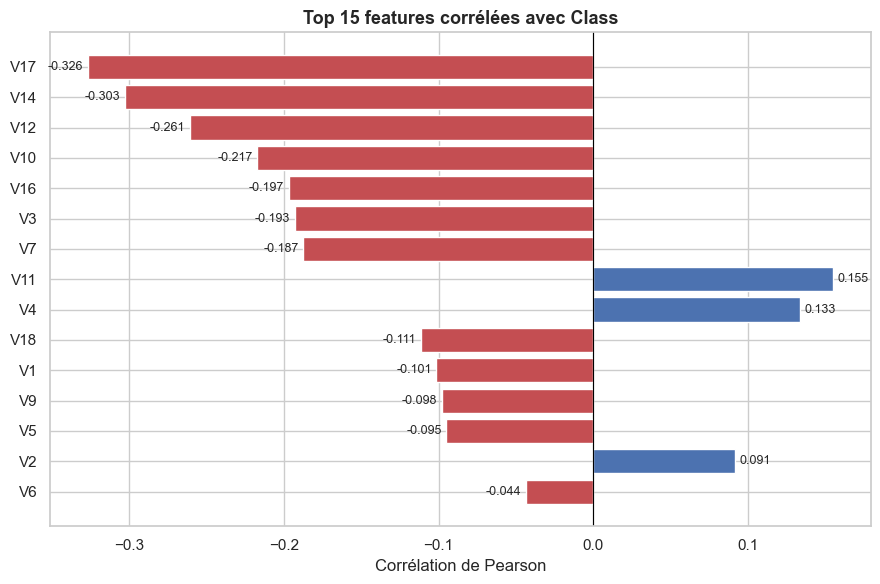

In [21]:
# Top corrélations avec Class — barplot lisible
top15 = corr_target.head(15)
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in top15.values]

plt.figure(figsize=(9, 6))
bars = plt.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Corrélation de Pearson')
plt.title('Top 15 features corrélées avec Class', fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15.values[::-1]):
    plt.text(val + (0.003 if val > 0 else -0.003), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}05_top_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── 3.2 VIF — Variance Inflation Factor ──────────────────────────
# Interprétation : VIF=1 (aucune corrélation), >5 (à surveiller), >10 (problématique)

X_for_vif = df_eng.drop(columns=['Class'])
X_const   = add_constant(X_for_vif)

print('Calcul VIF en cours...')
vif = pd.DataFrame()
vif['Feature'] = X_for_vif.columns
vif['VIF']     = [variance_inflation_factor(X_const.values, i+1)
                  for i in range(X_for_vif.shape[1])]
vif = vif.sort_values('VIF', ascending=False).reset_index(drop=True)

def vif_label(v):
    if v > 10: return '🔴 ÉLEVÉ'
    if v > 5:  return '🟡 MODÉRÉ'
    return            '🟢 OK'

vif['Status'] = vif['VIF'].apply(vif_label)

print('\n═══════════════════════════════════════════')
print('         VARIANCE INFLATION FACTOR         ')
print('═══════════════════════════════════════════')
print(vif.to_string(index=False))

high = vif[vif['VIF'] > 10]
if len(high) > 0:
    print(f'\n⚠️  {len(high)} features avec VIF > 10 — considérer la suppression :')
    print(high[['Feature','VIF']].to_string(index=False))
else:
    print('\n✅ Aucune multicolinéarité sévère (VIF < 10 pour toutes les features)')
    print('   (Résultat attendu : V1-V28 sont orthogonaux par construction PCA)')

Calcul VIF en cours...

═══════════════════════════════════════════
         VARIANCE INFLATION FACTOR         
═══════════════════════════════════════════
   Feature      VIF Status
Amount_log 1.646476   🟢 OK
      Hour 1.360025   🟢 OK
        V2 1.333521   🟢 OK
       V12 1.168702   🟢 OK
        V5 1.137799   🟢 OK
        V9 1.061603   🟢 OK
       V13 1.048134   🟢 OK
        V6 1.044285   🟢 OK
       V14 1.036561   🟢 OK
       V20 1.034508   🟢 OK
       V11 1.029655   🟢 OK
       V15 1.023430   🟢 OK
       V16 1.016206   🟢 OK
        V1 1.015393   🟢 OK
        V7 1.015109   🟢 OK
       V21 1.011789   🟢 OK
       V17 1.006054   🟢 OK
       V22 1.003566   🟢 OK
       V27 1.003378   🟢 OK
       V18 1.003030   🟢 OK
        V3 1.002618   🟢 OK
        V8 1.002023   🟢 OK
        V4 1.001729   🟢 OK
       V23 1.001498   🟢 OK
       V19 1.001017   🟢 OK
       V10 1.000918   🟢 OK
       V24 1.000412   🟢 OK
       V26 1.000372   🟢 OK
       V28 1.000083   🟢 OK
       V25 1.000036   🟢 OK

✅ Aucu

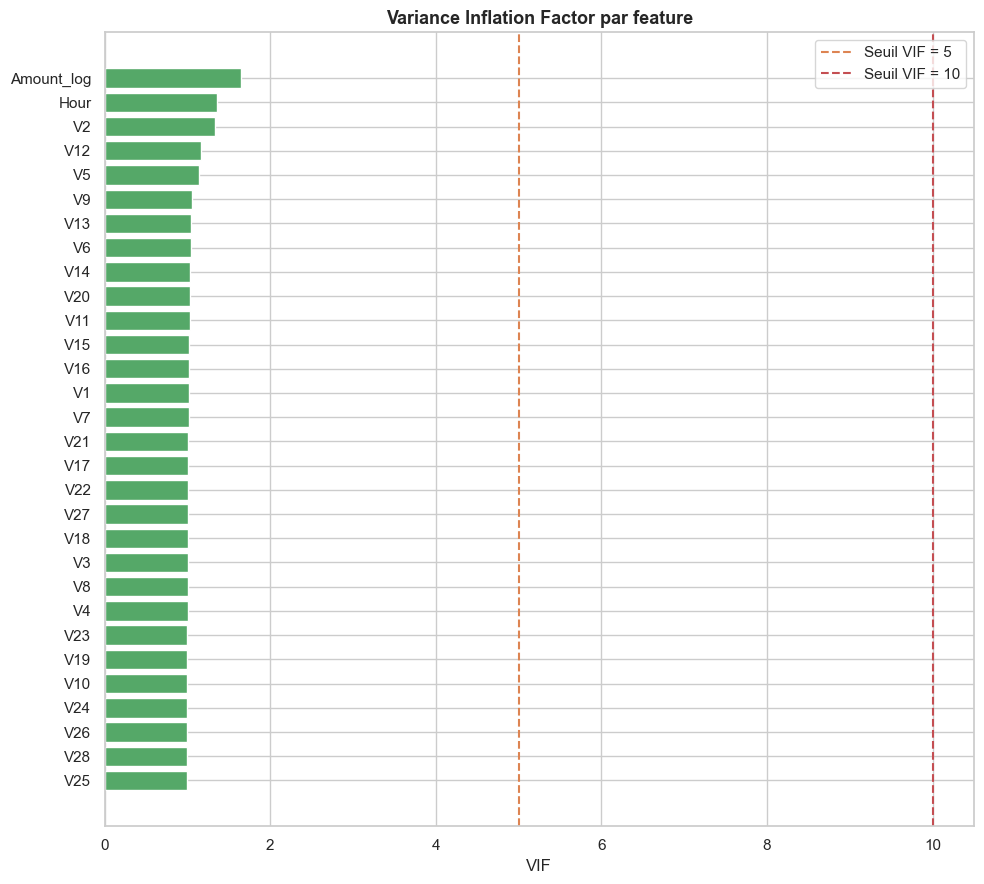

In [23]:
# Visualisation VIF
plt.figure(figsize=(10, 9))
colors_vif = ['#C44E52' if v > 10 else '#DD8452' if v > 5 else '#55A868' for v in vif['VIF']]
plt.barh(vif['Feature'][::-1], vif['VIF'][::-1], color=colors_vif[::-1], edgecolor='white')
plt.axvline(5,  color='#DD8452', linestyle='--', linewidth=1.5, label='Seuil VIF = 5')
plt.axvline(10, color='#C44E52', linestyle='--', linewidth=1.5, label='Seuil VIF = 10')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor par feature', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}06_vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Split Train / Validation / Test

In [24]:
X = df_eng.drop(columns=['Class'])
y = df_eng['Class']

# Split stratifié — OBLIGATOIRE avec données très déséquilibrées
# stratify=y garantit que chaque split a le même ratio fraude/légitime
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=VAL_SIZE,
    random_state=RANDOM_SEED,
    stratify=y_trainval
)

print('═══════════════════════════════════════════════════')
print('                  SPLITS CRÉÉS                    ')
print('═══════════════════════════════════════════════════')
for name, X_, y_ in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    n_fraud = y_.sum()
    print(f'  {name:<6} : {len(X_):>7,} lignes  |  '
          f'fraude : {n_fraud:>3} ({y_.mean()*100:.3f}%)  |  '
          f'{len(X_)/len(X)*100:.0f}% du total')
print('═══════════════════════════════════════════════════')
print('\n✅ Stratification OK — ratio fraude identique dans chaque split')

═══════════════════════════════════════════════════
                  SPLITS CRÉÉS                    
═══════════════════════════════════════════════════
  Train  : 205,060 lignes  |  fraude : 355 (0.173%)  |  72% du total
  Val    :  22,785 lignes  |  fraude :  39 (0.171%)  |  8% du total
  Test   :  56,962 lignes  |  fraude :  98 (0.172%)  |  20% du total
═══════════════════════════════════════════════════

✅ Stratification OK — ratio fraude identique dans chaque split


---
## 5. Comparaison : Approche Données vs Approche Algorithmique

> **Objectif :** Mesurer l'impact de chaque stratégie sur un modèle simple (LR).  
> Ce n'est PAS la modélisation finale — c'est l'analyse de l'Étape 1.  
> SMOTE est appliqué **uniquement sur X_train** — jamais sur val/test.

In [25]:
# Scaler — fit sur train uniquement
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

def evaluate(y_true, y_pred, y_proba, label):
    """Métriques partagées — PAS d'accuracy"""
    return {
        'Approche' : label,
        'F1-Macro' : round(f1_score(y_true, y_pred, average='macro'), 4),
        'AUPRC'    : round(average_precision_score(y_true, y_proba), 4),
        'MCC'      : round(matthews_corrcoef(y_true, y_pred), 4)
    }

results = []
print('Évaluation en cours...')

Évaluation en cours...


In [26]:
# ── Approche 1 : Sans correction (baseline) ───────────────────────
lr_base = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_base.fit(X_train_sc, y_train)
results.append(evaluate(y_val,
                         lr_base.predict(X_val_sc),
                         lr_base.predict_proba(X_val_sc)[:,1],
                         'Aucune correction (baseline)'))
print('✅ Baseline')

✅ Baseline


In [27]:
# ── Approche 2 : class_weight (algorithmique) ─────────────────────
lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
lr_cw.fit(X_train_sc, y_train)
results.append(evaluate(y_val,
                         lr_cw.predict(X_val_sc),
                         lr_cw.predict_proba(X_val_sc)[:,1],
                         'class_weight (algorithmique)'))
print('✅ class_weight')

✅ class_weight


In [28]:
# ── Approche 3 : SMOTE (niveau données) ───────────────────────────
# ⚠️  T490s : SMOTE sur 200k+ lignes prend 3-5 min — normal
print('SMOTE en cours... (peut prendre quelques minutes)')
smote = SMOTE(random_state=RANDOM_SEED)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_sc, y_train)
print(f'  Avant : {dict(pd.Series(y_train).value_counts())}')
print(f'  Après : {dict(pd.Series(y_tr_sm).value_counts())}')

lr_sm = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_sm.fit(X_tr_sm, y_tr_sm)
results.append(evaluate(y_val,
                         lr_sm.predict(X_val_sc),
                         lr_sm.predict_proba(X_val_sc)[:,1],
                         'SMOTE (niveau données)'))
print('✅ SMOTE')

SMOTE en cours... (peut prendre quelques minutes)
  Avant : {0: np.int64(204705), 1: np.int64(355)}
  Après : {0: np.int64(204705), 1: np.int64(204705)}
✅ SMOTE


In [29]:
# ── Approche 4 : ADASYN (niveau données) ──────────────────────────
print('ADASYN en cours...')
adasyn = ADASYN(random_state=RANDOM_SEED)
X_tr_ada, y_tr_ada = adasyn.fit_resample(X_train_sc, y_train)

lr_ada = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_ada.fit(X_tr_ada, y_tr_ada)
results.append(evaluate(y_val,
                         lr_ada.predict(X_val_sc),
                         lr_ada.predict_proba(X_val_sc)[:,1],
                         'ADASYN (niveau données)'))
print('✅ ADASYN')

ADASYN en cours...
✅ ADASYN


═══════════════════════════════════════════════════════════
     COMPARAISON DES APPROCHES DE DÉSÉQUILIBRE            
═══════════════════════════════════════════════════════════
                              F1-Macro   AUPRC     MCC
Approche                                              
Aucune correction (baseline)    0.8331  0.6575  0.6775
class_weight (algorithmique)    0.5468  0.6142  0.2150
SMOTE (niveau données)          0.5430  0.6128  0.2040
ADASYN (niveau données)         0.5019  0.5748  0.1252


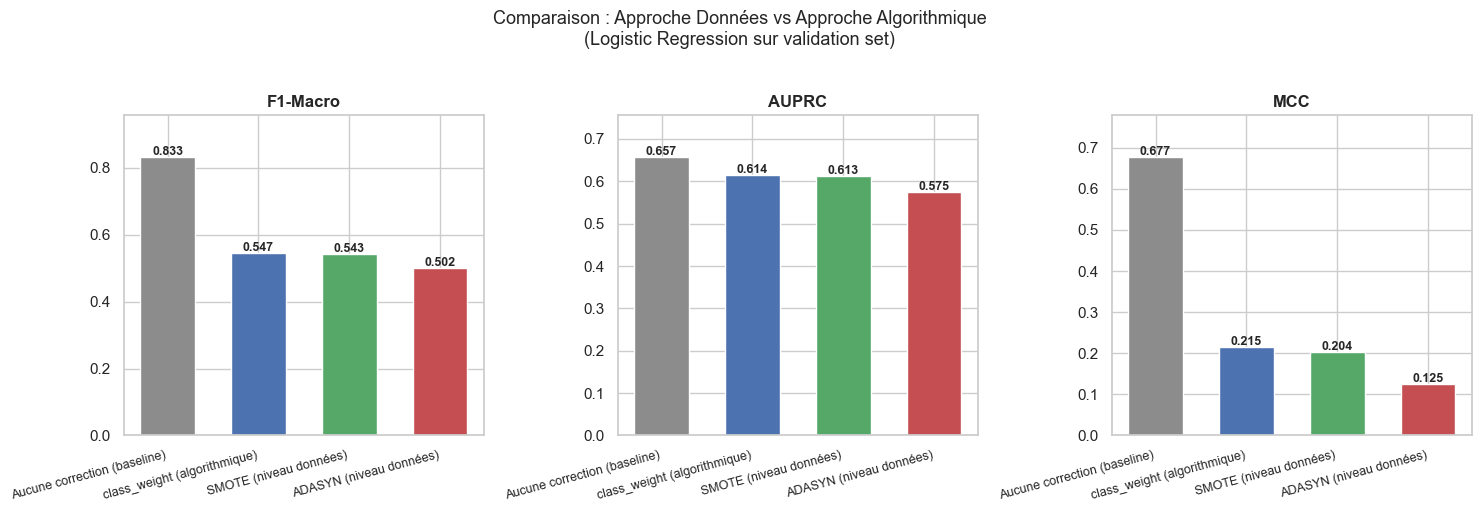


📌 Meilleure approche F1-Macro : Aucune correction (baseline)
📌 Meilleure approche MCC      : Aucune correction (baseline)


In [30]:
# ── Tableau comparatif ────────────────────────────────────────────
results_df = pd.DataFrame(results).set_index('Approche')

print('═══════════════════════════════════════════════════════════')
print('     COMPARAISON DES APPROCHES DE DÉSÉQUILIBRE            ')
print('═══════════════════════════════════════════════════════════')
print(results_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['F1-Macro', 'AUPRC', 'MCC']
palette = ['#8C8C8C', '#4C72B0', '#55A868', '#C44E52']

for i, metric in enumerate(metrics):
    vals = results_df[metric]
    bars = axes[i].bar(range(len(vals)), vals.values, color=palette, edgecolor='white', width=0.6)
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=15, ha='right', fontsize=9)
    axes[i].set_title(metric, fontsize=12, fontweight='bold')
    axes[i].set_ylim(0, min(1.0, vals.max() * 1.15))
    for bar, v in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison : Approche Données vs Approche Algorithmique\n(Logistic Regression sur validation set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_PATH}07_imbalance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_f1  = results_df['F1-Macro'].idxmax()
best_mcc = results_df['MCC'].idxmax()
print(f'\n📌 Meilleure approche F1-Macro : {best_f1}')
print(f'📌 Meilleure approche MCC      : {best_mcc}')

---
## 6. Export des Splits pour l'Équipe

In [31]:
# Reconstruire les DataFrames avec les noms de colonnes
cols = X.columns.tolist()

train_df = pd.DataFrame(X_train.values, columns=cols)
train_df['Class'] = y_train.values

val_df = pd.DataFrame(X_val.values, columns=cols)
val_df['Class'] = y_val.values

test_df = pd.DataFrame(X_test.values, columns=cols)
test_df['Class'] = y_test.values

# Export
train_df.to_csv(f'{PROCESSED_PATH}train.csv', index=False)
val_df.to_csv(  f'{PROCESSED_PATH}val.csv',   index=False)
test_df.to_csv( f'{PROCESSED_PATH}test.csv',  index=False)
df_eng.to_csv(  f'{PROCESSED_PATH}clean_dataset.csv', index=False)

print('═══════════════════════════════════════════════════════════')
print('                  FICHIERS EXPORTÉS ✅                    ')
print('═══════════════════════════════════════════════════════════')
print(f'  train.csv         {len(train_df):>8,} lignes  →  {train_df["Class"].sum()} fraudes')
print(f'  val.csv           {len(val_df):>8,} lignes  →  {val_df["Class"].sum()} fraudes')
print(f'  test.csv          {len(test_df):>8,} lignes  →  {test_df["Class"].sum()} fraudes')
print(f'  clean_dataset.csv {len(df_eng):>8,} lignes  (dataset complet)')
print('═══════════════════════════════════════════════════════════')
print()
print('⚠️  RÈGLES POUR TOUTE L\'ÉQUIPE :')
print('   1. Utiliser UNIQUEMENT ces fichiers — ne pas re-splitter')
print('   2. SMOTE/ADASYN : appliquer sur train.csv UNIQUEMENT')
print('   3. Ne pas toucher test.csv avant l\'évaluation finale')
print('   4. Scaler : fit sur train, transform sur val et test')

═══════════════════════════════════════════════════════════
                  FICHIERS EXPORTÉS ✅                    
═══════════════════════════════════════════════════════════
  train.csv          205,060 lignes  →  355 fraudes
  val.csv             22,785 lignes  →  39 fraudes
  test.csv            56,962 lignes  →  98 fraudes
  clean_dataset.csv  284,807 lignes  (dataset complet)
═══════════════════════════════════════════════════════════

⚠️  RÈGLES POUR TOUTE L'ÉQUIPE :
   1. Utiliser UNIQUEMENT ces fichiers — ne pas re-splitter
   2. SMOTE/ADASYN : appliquer sur train.csv UNIQUEMENT
   3. Ne pas toucher test.csv avant l'évaluation finale
   4. Scaler : fit sur train, transform sur val et test


---
## 7. Résumé — À Copier dans le Rapport

| Élément | Résultat |
|---|---|
| **Shape** | 284,807 × 31 |
| **Valeurs manquantes** | Aucune |
| **Déséquilibre** | ~0.17% fraude — ratio 578:1 |
| **V1–V28** | Orthogonaux par construction (PCA) — VIF faible confirmé |
| **Features créées** | `Amount_log`, `Hour`, `Is_night` |
| **Features supprimées** | `Time`, `Amount` (remplacées) |
| **Meilleure approche déséquilibre** | *À compléter après résultats* |
| **Features VIF > 10** | *À compléter après analyse* |

### Justification des métriques utilisées (Étape 3)
- **F1-Macro** : équilibre précision/rappel pour les deux classes, pénalise les modèles qui ignorent la classe minoritaire
- **AUPRC** : plus informatif que AUC-ROC en contexte déséquilibré — mesure la qualité de la prédiction sur la classe positive
- **MCC** : seule métrique qui prend en compte tous les quadrants de la matrice de confusion — robuste au déséquilibre
- **Accuracy exclue** : un modèle prédisant tout "légitime" aurait 99.83% d'accuracy — métrique trompeuse